In [1]:
import pandas as pd
import numpy as np
import pickle
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import AgglomerativeClustering, KMeans, DBSCAN
from sklearn.preprocessing import StandardScaler
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import pdist, squareform
import warnings
warnings.filterwarnings('ignore')

# Set paths
DATA_DIR = Path('./data')
OUTPUT_DIR = Path('./data')
FIGURES_DIR = Path('./figures')
FIGURES_DIR.mkdir(exist_ok=True)

# Set style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 8)

print("Hierarchical Clustering Pipeline Started")
print("=" * 50)

Hierarchical Clustering Pipeline Started


## 1. Load Test Features

In [2]:
# Load test features (use noisy version if available, otherwise original)
if (DATA_DIR / 'test_features_noisy.pkl').exists():
    with open(DATA_DIR / 'test_features_noisy.pkl', 'rb') as f:
        test_df = pickle.load(f)
    print("Loaded noise-augmented test features")
else:
    with open(DATA_DIR / 'test_features.pkl', 'rb') as f:
        test_df = pickle.load(f)
    print("Loaded original test features")

print(f"Test data shape: {test_df.shape}")

# Extract numeric features
acc_ids = test_df['account'].values
feature_cols = [col for col in test_df.columns if col not in ['account', 'label']]
numeric_cols = test_df[feature_cols].select_dtypes(include=[np.number]).columns.tolist()

print(f"Numeric features: {len(numeric_cols)}")
print(f"Test accounts: {len(acc_ids)}")

Loaded noise-augmented test features
Test data shape: (7558, 6254)
Numeric features: 6252
Test accounts: 7558
Numeric features: 6252
Test accounts: 7558


## 2. Prepare Features for Clustering

In [3]:
# Extract feature matrix
X = test_df[numeric_cols].values

# Standardize
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"Feature matrix shape: {X_scaled.shape}")
print(f"Mean: {X_scaled.mean():.6f}")
print(f"Std: {X_scaled.std():.6f}")

Feature matrix shape: (7558, 6252)
Mean: -0.000000
Std: 1.000000
Std: 1.000000


## 3. Multi-Level Hierarchical Clustering

Create hierarchical groupings at multiple levels of granularity.

In [4]:
class HierarchicalGrouping:
    """
    Multi-level hierarchical clustering with arbitrary depth.
    """
    def __init__(self, X, acc_ids, method='ward', max_levels=5):
        self.X = X
        self.acc_ids = acc_ids
        self.n_samples = len(X)
        self.method = method
        self.max_levels = max_levels
        self.hierarchy = {}
        self.linkage_matrix = None
    
    def build_hierarchy(self, n_clusters_per_level=None):
        """
        Build hierarchical clustering at multiple levels.
        
        Args:
            n_clusters_per_level: List of number of clusters at each level
                                 If None, uses exponential decay: [10, 30, 100, 300, 1000]
        """
        if n_clusters_per_level is None:
            # Default: exponential increase in granularity
            n_clusters_per_level = [
                min(10, self.n_samples),
                min(30, self.n_samples),
                min(100, self.n_samples),
                min(300, self.n_samples),
                min(1000, self.n_samples)
            ][:self.max_levels]
        
        print(f"Building hierarchy with {len(n_clusters_per_level)} levels...")
        print(f"Clusters per level: {n_clusters_per_level}")
        
        # Compute linkage matrix once
        print("Computing linkage matrix...")
        self.linkage_matrix = linkage(self.X, method=self.method)
        
        # Extract clusters at each level
        for level, n_clusters in enumerate(n_clusters_per_level):
            if n_clusters >= self.n_samples:
                # Each sample is its own cluster
                labels = np.arange(self.n_samples)
            else:
                # Use AgglomerativeClustering with precomputed linkage
                clusterer = AgglomerativeClustering(
                    n_clusters=n_clusters,
                    linkage=self.method
                )
                labels = clusterer.fit_predict(self.X)
            
            self.hierarchy[f'level_{level}'] = {
                'n_clusters': n_clusters,
                'labels': labels,
                'cluster_sizes': pd.Series(labels).value_counts().to_dict()
            }
            
            label_counts = pd.Series(labels).value_counts()
            print(f"  Level {level}: {n_clusters} clusters, "
                  f"avg size: {self.n_samples / n_clusters:.1f}, "
                  f"min: {label_counts.min()}, "
                  f"max: {label_counts.max()}")
        
        return self.hierarchy
    
    def get_cluster_features(self):
        """
        Extract features for each cluster at each level.
        Useful for meta-learning.
        """
        cluster_features = []
        
        for level_name, level_data in self.hierarchy.items():
            labels = level_data['labels']
            
            for cluster_id in np.unique(labels):
                mask = labels == cluster_id
                cluster_X = self.X[mask]
                
                # Compute cluster statistics
                features = {
                    'level': level_name,
                    'cluster_id': cluster_id,
                    'size': mask.sum(),
                    'mean_feature': cluster_X.mean(axis=0).mean(),
                    'std_feature': cluster_X.std(axis=0).mean(),
                    'compactness': np.sqrt(((cluster_X - cluster_X.mean(axis=0))**2).sum(axis=1).mean()),
                    'diameter': np.max(pdist(cluster_X)) if len(cluster_X) > 1 else 0,
                }
                
                cluster_features.append(features)
        
        return pd.DataFrame(cluster_features)
    
    def get_account_memberships(self):
        """
        Create a table of account cluster memberships across all levels.
        """
        memberships = pd.DataFrame({'account': self.acc_ids})
        
        for level_name, level_data in self.hierarchy.items():
            memberships[f'cluster_{level_name}'] = level_data['labels']
        
        return memberships
    
    def plot_dendrogram(self, max_display=30):
        """
        Plot dendrogram (only top levels for readability).
        """
        if self.linkage_matrix is None:
            print("Build hierarchy first!")
            return
        
        plt.figure(figsize=(15, 8))
        dendrogram(
            self.linkage_matrix,
            truncate_mode='lastp',
            p=max_display,
            show_leaf_counts=True,
            leaf_font_size=10
        )
        plt.title(f'Hierarchical Clustering Dendrogram (top {max_display} merges)', fontsize=14)
        plt.xlabel('Cluster index or (sample count)', fontsize=12)
        plt.ylabel('Distance', fontsize=12)
        plt.tight_layout()
        return plt.gcf()

print("✓ HierarchicalGrouping class defined")

✓ HierarchicalGrouping class defined


## 4. Build Hierarchical Clusters

In [5]:
# Create hierarchical grouping
hierarchical = HierarchicalGrouping(
    X=X_scaled,
    acc_ids=acc_ids,
    method='ward',  # Ward linkage minimizes within-cluster variance
    max_levels=5
)

# Build hierarchy
hierarchy = hierarchical.build_hierarchy()

print(f"\n✓ Built hierarchical clustering with {len(hierarchy)} levels")

Building hierarchy with 5 levels...
Clusters per level: [10, 30, 100, 300, 1000]
Computing linkage matrix...
  Level 0: 10 clusters, avg size: 755.8, min: 1, max: 7471
  Level 0: 10 clusters, avg size: 755.8, min: 1, max: 7471
  Level 1: 30 clusters, avg size: 251.9, min: 1, max: 5086
  Level 1: 30 clusters, avg size: 251.9, min: 1, max: 5086
  Level 2: 100 clusters, avg size: 75.6, min: 1, max: 2323
  Level 2: 100 clusters, avg size: 75.6, min: 1, max: 2323
  Level 3: 300 clusters, avg size: 25.2, min: 1, max: 323
  Level 3: 300 clusters, avg size: 25.2, min: 1, max: 323
  Level 4: 1000 clusters, avg size: 7.6, min: 1, max: 184

✓ Built hierarchical clustering with 5 levels
  Level 4: 1000 clusters, avg size: 7.6, min: 1, max: 184

✓ Built hierarchical clustering with 5 levels


## 5. Extract Cluster Features

In [6]:
# Get cluster-level features
cluster_features = hierarchical.get_cluster_features()
print(f"Cluster features shape: {cluster_features.shape}")
print(f"\nSample cluster features:")
print(cluster_features.head(10))

# Get account memberships
account_memberships = hierarchical.get_account_memberships()
print(f"\nAccount memberships shape: {account_memberships.shape}")
print(f"\nSample memberships:")
print(account_memberships.head())

Cluster features shape: (1440, 7)

Sample cluster features:
     level  cluster_id  size  mean_feature  std_feature  compactness  \
0  level_0           0  7471     -0.009649     0.139153    20.972193   
1  level_0           1     8      2.158817     0.861740   186.706388   
2  level_0           2     2      1.797328     1.086482   264.564429   
3  level_0           3     2      1.717214     0.549415   225.319086   
4  level_0           4     1      9.558262     0.000000     0.000000   
5  level_0           5     3      2.060732     1.688348   219.437364   
6  level_0           6     1      0.270619     0.000000     0.000000   
7  level_0           7     1     -1.159415     0.000000     0.000000   
8  level_0           8    68      0.401757     0.330254    64.867176   
9  level_0           9     1      5.613674     0.000000     0.000000   

     diameter  
0  473.023417  
1  525.694135  
2  529.128858  
3  450.638172  
4    0.000000  
5  471.120113  
6    0.000000  
7    0.000000  
8  

## 6. Visualize Hierarchy

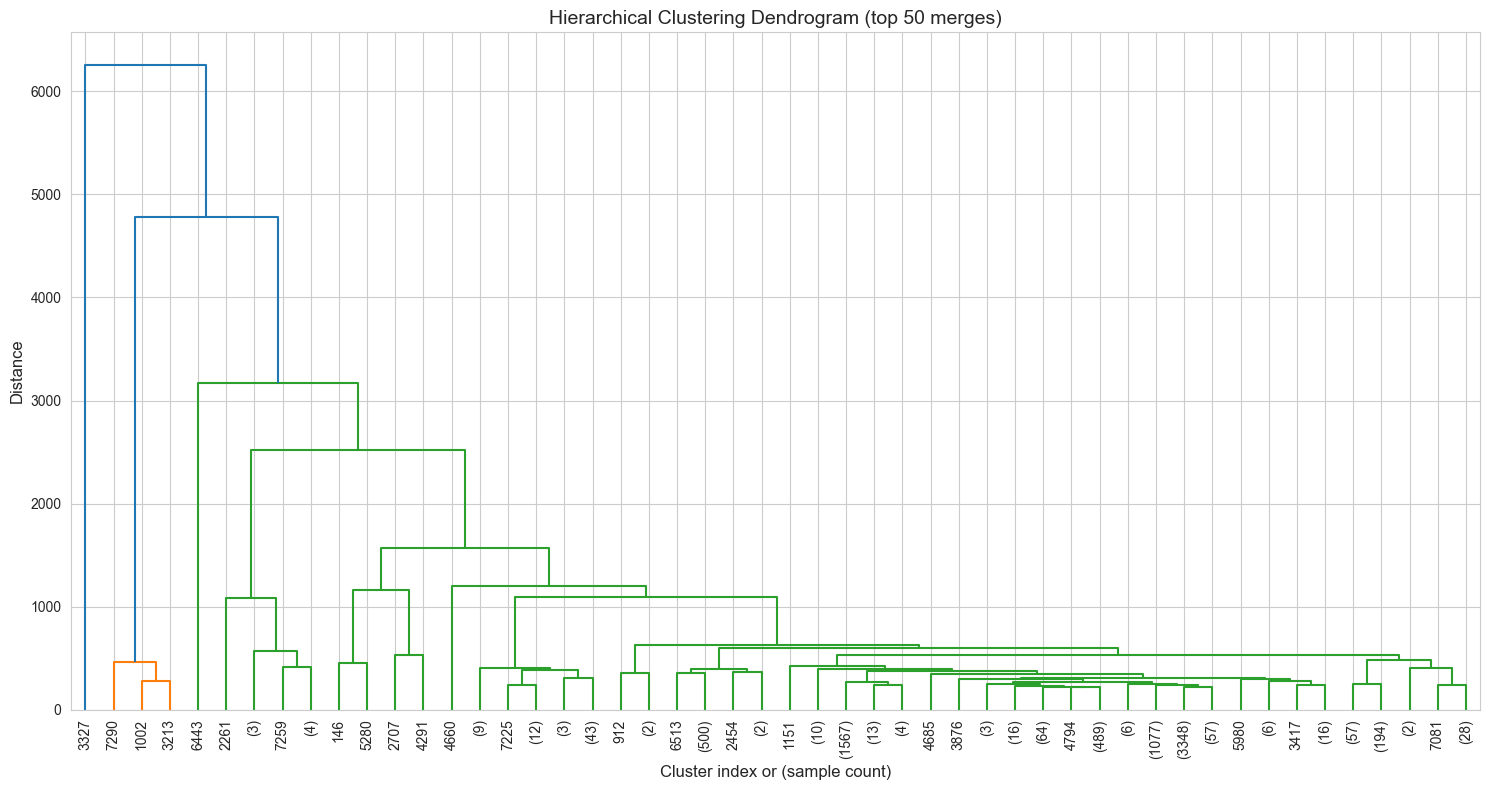

✓ Saved dendrogram to figures/cluster_dendrogram.png


In [7]:
# Plot dendrogram
fig = hierarchical.plot_dendrogram(max_display=50)
plt.savefig(FIGURES_DIR / 'cluster_dendrogram.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Saved dendrogram to figures/cluster_dendrogram.png")

## 7. Cluster Size Distributions

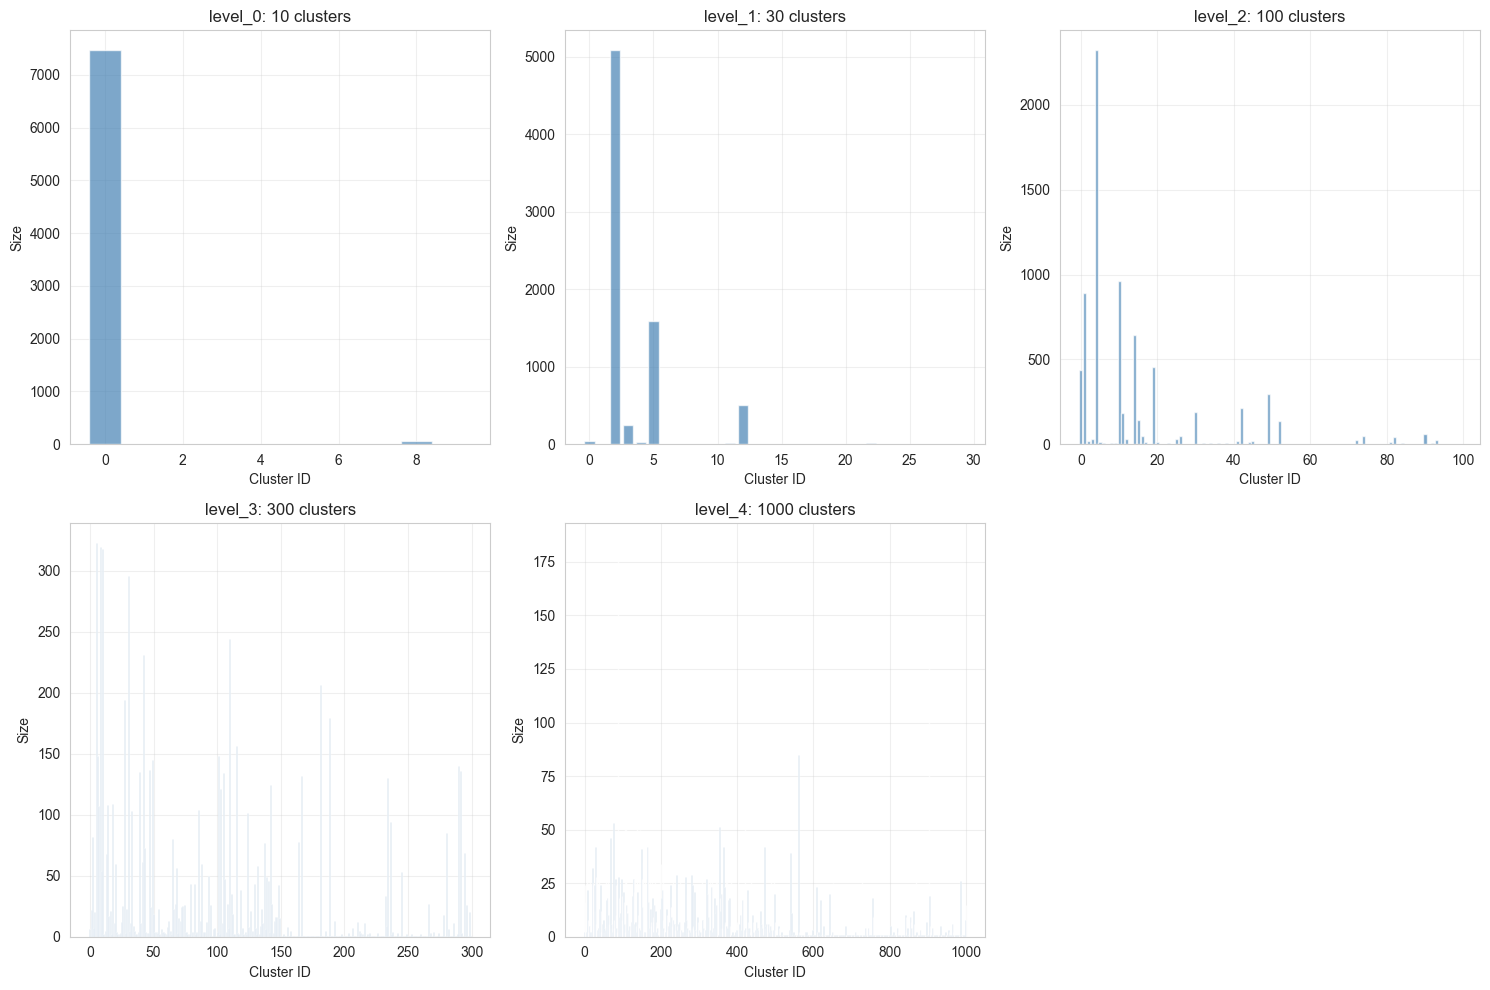

✓ Saved cluster size distributions


In [8]:
# Plot cluster size distributions at each level
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for idx, (level_name, level_data) in enumerate(hierarchy.items()):
    if idx >= len(axes):
        break
    
    sizes = pd.Series(level_data['labels']).value_counts().sort_index()
    
    axes[idx].bar(range(len(sizes)), sizes.values, alpha=0.7, color='steelblue')
    axes[idx].set_title(f"{level_name}: {level_data['n_clusters']} clusters")
    axes[idx].set_xlabel('Cluster ID')
    axes[idx].set_ylabel('Size')
    axes[idx].grid(alpha=0.3)

# Remove empty subplot
if len(hierarchy) < len(axes):
    fig.delaxes(axes[-1])

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'cluster_size_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Saved cluster size distributions")

## 8. Additional Clustering Methods (Optional)

Try alternative clustering algorithms for comparison.

In [9]:
# K-Means clustering (flat, not hierarchical)
kmeans_results = {}
for k in [10, 30, 100]:
    if k >= len(X_scaled):
        continue
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    kmeans_results[f'kmeans_{k}'] = {
        'labels': labels,
        'centers': kmeans.cluster_centers_,
        'inertia': kmeans.inertia_
    }
    print(f"K-Means (k={k}): inertia={kmeans.inertia_:.2f}")

print(f"\n✓ Created {len(kmeans_results)} K-Means clusterings")

K-Means (k=10): inertia=4246154.08
K-Means (k=30): inertia=2228411.69
K-Means (k=30): inertia=2228411.69
K-Means (k=100): inertia=828528.03

✓ Created 3 K-Means clusterings
K-Means (k=100): inertia=828528.03

✓ Created 3 K-Means clusterings


## 9. Save Outputs

In [10]:
# Package all clustering results
clustering_data = {
    'hierarchy': hierarchy,
    'hierarchical_object': hierarchical,
    'account_memberships': account_memberships,
    'cluster_features': cluster_features,
    'kmeans_results': kmeans_results,
    'scaler': scaler,
    'feature_cols': numeric_cols
}

with open(OUTPUT_DIR / 'cluster_hierarchy.pkl', 'wb') as f:
    pickle.dump(clustering_data, f)
print("✓ Saved cluster_hierarchy.pkl")

# Save cluster features separately for easy loading
with open(OUTPUT_DIR / 'cluster_features.pkl', 'wb') as f:
    pickle.dump(cluster_features, f)
print("✓ Saved cluster_features.pkl")

# Save account memberships as CSV for easy inspection
account_memberships.to_csv(OUTPUT_DIR / 'account_cluster_memberships.csv', index=False)
print("✓ Saved account_cluster_memberships.csv")

print("\n" + "="*50)
print("Hierarchical Clustering Complete!")
print("="*50)
print(f"\nClustering summary:")
print(f"  Hierarchical levels: {len(hierarchy)}")
print(f"  Test accounts: {len(acc_ids)}")
print(f"  Cluster features: {cluster_features.shape}")
print(f"  Alternative methods: {len(kmeans_results)}")

✓ Saved cluster_hierarchy.pkl
✓ Saved cluster_features.pkl
✓ Saved account_cluster_memberships.csv

Hierarchical Clustering Complete!

Clustering summary:
  Hierarchical levels: 5
  Test accounts: 7558
  Cluster features: (1440, 7)
  Alternative methods: 3
